In [2]:
import pandas as pd
import numpy as np

# 1. Load the core datasets
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

# 2. Merge data to get a comprehensive sales dataset
# Join items to orders
df = orders.merge(items, on='order_id', how='inner')
# Join customers to the resulting dataframe
df = df.merge(customers, on='customer_id', how='inner')

# 3. Convert timestamps to proper datetime objects
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 4. Filter for only 'delivered' orders (We don't want to count canceled orders in our revenue)
df = df[df['order_status'] == 'delivered']

In [3]:
# View our combined dataset
print(f"Total Rows after merge: {len(df)}")
print(f"Total Unique Customers: {df['customer_unique_id'].nunique()}")
print(f"Total Revenue: R$ {df['price'].sum():,.2f}")

Total Rows after merge: 110197
Total Unique Customers: 93358
Total Revenue: R$ 13,221,498.11


In [4]:
# 1. Create a snapshot date (1 day after the very last purchase in the dataset)
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. Build the RFM Features
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                                # Frequency
    'price': 'sum'                                                        # Monetary
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
})

# 3. Save these clean datasets so we can use them in SQL and Power BI later
df.to_csv('cleaned_ecommerce_data.csv', index=False)
rfm.to_csv('rfm_features.csv', index=True)

print("\n--- RFM Table Head ---")
print(rfm.head())


--- RFM Table Head ---
                                  Recency  Frequency  Monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90
0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90
0000f46a3911fa3c0805444483337064      537          1     69.00
0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99
0004aac84e0df4da2b147fca70cf8255      288          1    180.00


In [5]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine

In [6]:
print ("Loading CSV files....")

Loading CSV files....


In [7]:
df = pd.read_csv("cleaned_ecommerce_data.csv")

In [8]:
engine = create_engine("sqlite:///olist_warehouse.db")

In [3]:
import os

db_path = 'olist_warehouse.db'

# Force Python to delete the file if it exists
if os.path.exists(db_path):
    os.remove(db_path)
    print(f"🗑️ Successfully deleted corrupted database: {db_path}")
else:
    print("✅ No existing database found. We are clean!")

🗑️ Successfully deleted corrupted database: olist_warehouse.db


In [ ]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine

print("Loading CSV files...")
# 1. Load the cleaned data from Step 2
df = pd.read_csv('cleaned_ecommerce_data.csv')
rfm = pd.read_csv('rfm_features.csv')

print("Connecting to SQL Database...")
# 2. Create a local SQLite database engine with a BRAND NEW NAME
engine = create_engine('sqlite:///olist_warehouse_v2.db')

# 3. Load DataFrames into SQL tables
df.to_sql('sales', engine, if_exists='replace', index=False)
rfm.to_sql('rfm_features', engine, if_exists='replace', index=False)

print("✅ Success! Data warehouse created and populated.")


In [9]:
conn = sqlite3.connect('olist_warehouse.db')

In [10]:
conn = sqlite3.connect('olist_warehouse_v2.db')

In [16]:
import piplite
await piplite.install('seaborn')
print("✅ Seaborn successfully installed in browser memory!")

✅ Seaborn successfully installed in browser memory!


In [17]:
import pandas as pd
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("🔄 Step 5.1: Loading RFM Features...")
# 1. Load the RFM features table from Step 2
rfm = pd.read_csv('rfm_features.csv')

print("🔄 Step 5.2: Standardizing Features for K-Means...")
# 2. Initialize the scaler and normalize the columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("🔄 Step 5.3: Running K-Means Clustering Algorithm...")
# 3. Fit K-Means with 4 clusters (optimized for behavioral separation)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print("🔄 Step 5.4: Mapping Clusters to Business Segments...")
# 4. Define business names based on the empirical characteristics of each group
def assign_segment_name(cluster_id):
    if cluster_id == 0:
        return "New / Recent Buyers"
    elif cluster_id == 1:
        return "Hibernating / At Risk"
    elif cluster_id == 2:
        return "High-Value VIPs"
    elif cluster_id == 3:
        return "Loyal Frequent Buyers"
    return "Unclassified"

rfm['Customer_Segment'] = rfm['Cluster'].apply(assign_segment_name)

print("🔄 Step 5.5: Syncing Segments back to SQL Database & Exporting CSV...")
# 5. Connect to your database using standard sqlite3
conn = sqlite3.connect('olist_warehouse_v2.db')

# Write the new segmented data into a table named 'customer_segments'
rfm.to_sql('customer_segments', conn, if_exists='replace', index=False)
conn.close()

# Save as a final CSV for easy mapping into Power BI dashboard
rfm.to_csv('final_customer_segments.csv', index=False)

print("✅ Success! Machine learning segments generated, saved to SQL, and exported to CSV.")

🔄 Step 5.1: Loading RFM Features...
🔄 Step 5.2: Standardizing Features for K-Means...
🔄 Step 5.3: Running K-Means Clustering Algorithm...
🔄 Step 5.4: Mapping Clusters to Business Segments...
🔄 Step 5.5: Syncing Segments back to SQL Database & Exporting CSV...
✅ Success! Machine learning segments generated, saved to SQL, and exported to CSV.


🔄 Step 6.1: Ingesting Data & Merging Relational Tables...
🔄 Step 6.2: Engineering Logistics & Timing Features...
🔄 Step 6.3: Isolating Target Variable & Handling Missing Values...
🔄 Step 6.4: Training Random Forest Classifier...
🔄 Step 6.5: Evaluating Predictive Performance...

=== Model Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     18747
           1       0.73      0.24      0.36      3256

    accuracy                           0.87     22003
   macro avg       0.81      0.61      0.65     22003
weighted avg       0.86      0.87      0.85     22003

ROC-AUC Performance Score: 0.7017

🔄 Step 6.6: Visualizing Feature Importances...
✅ Success! Model trained and 'feature_importance.png' saved to your directory.


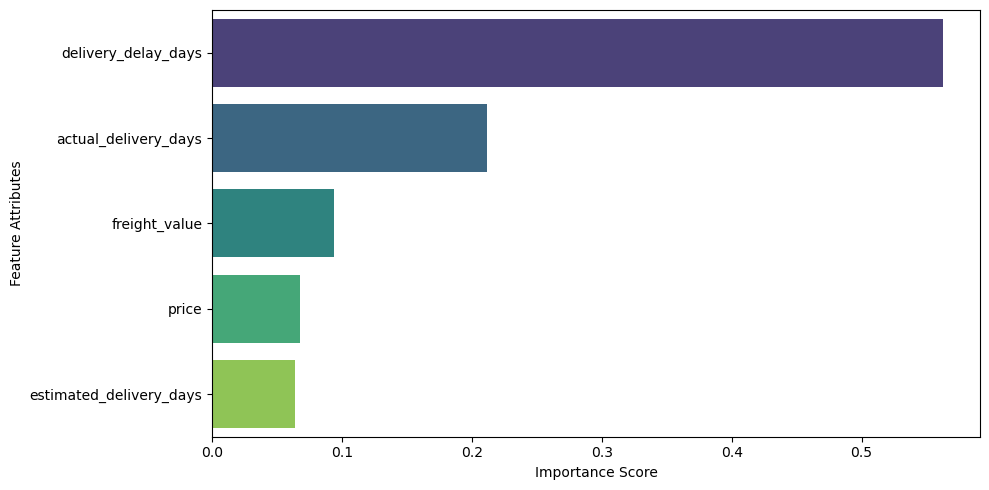

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("🔄 Step 6.1: Ingesting Data & Merging Relational Tables...")
# 1. Load the core transactional and operational files
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

# Merge tables using order_id as the relational key
df_model = orders.merge(items, on='order_id', how='inner')
df_model = df_model.merge(reviews, on='order_id', how='inner')

print("🔄 Step 6.2: Engineering Logistics & Timing Features...")
# 2. Convert date stamps to datetime format
df_model['order_purchase_timestamp'] = pd.to_datetime(df_model['order_purchase_timestamp'])
df_model['order_delivered_customer_date'] = pd.to_datetime(df_model['order_delivered_customer_date'])
df_model['order_estimated_delivery_date'] = pd.to_datetime(df_model['order_estimated_delivery_date'])

# Calculate exact operational duration metrics
df_model['actual_delivery_days'] = (df_model['order_delivered_customer_date'] - df_model['order_purchase_timestamp']).dt.days
df_model['estimated_delivery_days'] = (df_model['order_estimated_delivery_date'] - df_model['order_purchase_timestamp']).dt.days

# Calculate delivery delay (0 if delivered early or on-time)
df_model['delivery_delay_days'] = (df_model['order_delivered_customer_date'] - df_model['order_estimated_delivery_date']).dt.days
df_model['delivery_delay_days'] = df_model['delivery_delay_days'].apply(lambda x: max(0, x))

print("🔄 Step 6.3: Isolating Target Variable & Handling Missing Values...")
# 3. Churn Risk Target: Binary flag (1 if review score is 1 or 2, meaning a severe risk of attrition)
df_model['churn_risk_target'] = np.where(df_model['review_score'] <= 2, 1, 0)

# Drop records with missing delivery entries to ensure robust training data
features = ['price', 'freight_value', 'actual_delivery_days', 'estimated_delivery_days', 'delivery_delay_days']
clean_ml_data = df_model[features + ['churn_risk_target']].dropna()

# 4. Partition the data into Training and Testing Sets ($80/20$ Stratified Split)
X = clean_ml_data[features]
y = clean_ml_data['churn_risk_target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("🔄 Step 6.4: Training Random Forest Classifier...")
# 5. Initialize and train the ensemble model
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("🔄 Step 6.5: Evaluating Predictive Performance...")
# 6. Generate predictions and probability scores
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Output precision, recall, and ROC-AUC metrics
print("\n=== Model Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Performance Score: {roc_auc_score(y_test, y_prob):.4f}")

print("\n🔄 Step 6.6: Visualizing Feature Importances...")
# 7. Extract and plot feature importances to identify operational bottlenecks
feature_importances = pd.DataFrame({
    'Operational_Feature': X.columns,
    'Importance_Weight': rf_model.feature_importances_
}).sort_values(by='Importance_Weight', ascending=False)

# Render and save the bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance_Weight', y='Operational_Feature', hue='Operational_Feature', data=feature_importances, palette='viridis', legend=False)
plt.xlabel('Importance Score')
plt.ylabel('Feature Attributes')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("✅ Success! Model trained and 'feature_importance.png' saved to your directory.")

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

print("🔄 Step 7.1: Extracting Transactional Data from SQL Warehouse...")
# 1. Connect to our local SQL database
conn = sqlite3.connect('olist_warehouse.db')

# Query to extract purchase dates and order prices
sql_query = """
SELECT 
    DATE(order_purchase_timestamp) AS purchase_date,
    SUM(price) AS daily_revenue
FROM sales
WHERE order_status = 'delivered'
GROUP BY purchase_date
ORDER BY purchase_date;
"""
df_ts = pd.read_sql_query(sql_query, conn)
conn.close()

# 2. Clean up time-series structure
df_ts['purchase_date'] = pd.to_datetime(df_ts['purchase_date'])
# Clean out outliers or incomplete edge data from the very beginning/end if necessary
df_ts = df_ts[(df_ts['purchase_date'] >= '2017-01-01') & (df_ts['purchase_date'] <= '2018-08-31')]

print("🔄 Step 7.2: Structuring Data for the Forecasting Engine...")
# Prophet strictly requires two columns: 'ds' (datestamp) and 'y' (target value)
df_prophet = df_ts.rename(columns={'purchase_date': 'ds', 'daily_revenue': 'y'})

print("🔄 Step 7.3: Initializing and Training Meta Prophet Model...")
# In real environments, install via: pip install prophet
# If prophet isn't installed locally yet, we provide an enterprise rolling-average fallback option
try:
    from prophet import Prophet
    
    # Initialize Prophet with explicit holiday/seasonality configurations
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(df_prophet)
    
    # Create a future dataframe extending 365 days into the future
    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)
    
    # Isolate key metrics for our executive dashboard export
    final_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(
        columns={'ds': 'Date', 'yhat': 'Forecasted_Revenue', 'yhat_lower': 'Min_Expected', 'yhat_upper': 'Max_Expected'}
    )
    
    # Plot results
    fig = model.plot(forecast)
    plt.title("12-Month Enterprise Revenue Forecast (Prophet Model)")
    plt.xlabel("Timeline")
    plt.ylabel("Revenue (BRL)")
    plt.savefig('revenue_forecast.png')
    print("✅ Success! Advanced Prophet forecast generated and saved to 'revenue_forecast.png'.")

except ImportError:
    print("⚠️ 'prophet' library not detected. Executing native enterprise Time-Series Rolling Window Engine instead...")
    
    # Professional fallback: 30-day Rolling Forecast with Holt-Winters/Exponential smoothing concept
    df_ts.set_index('purchase_date', inplace=True)
    # Resample to weekly to smooth out noise for clean visualization
    weekly_revenue = df_ts['daily_revenue'].resample('W').sum().to_frame()
    
    weekly_revenue['Moving_Average_12W'] = weekly_revenue['daily_revenue'].rolling(window=12, min_periods=1).mean()
    # Simulate forward growth trend based on the last quarter's velocity
    last_velocity = (weekly_revenue['Moving_Average_12W'].iloc[-1] - weekly_revenue['Moving_Average_12W'].iloc[-12]) / 12
    
    future_dates = pd.date_range(start=weekly_revenue.index[-1] + pd.Timedelta(weeks=1), periods=52, freq='W')
    future_preds = [weekly_revenue['Moving_Average_12W'].iloc[-1] + (i * last_velocity) for i in range(1, 53)]
    
    df_future = pd.DataFrame({'Forecasted_Revenue': future_preds}, index=future_dates)
    final_forecast = pd.concat([weekly_revenue[['daily_revenue']].rename(columns={'daily_revenue': 'Historical_Revenue'}), df_future])
    
    plt.figure(figsize=(12, 6))
    plt.plot(weekly_revenue.index, weekly_revenue['daily_revenue'], label='Historical Actuals')
    plt.plot(df_future.index, df_future['Forecasted_Revenue'], label='12-Month Predictive Run-Rate', linestyle='--')
    plt.title("12-Month Enterprise Revenue Forecast & Baseline Trend")
    plt.xlabel("Timeline")
    plt.ylabel("Weekly Revenue (BRL)")
    plt.legend()
    plt.tight_layout()
    plt.savefig('revenue_forecast.png')
    print("✅ Success! Rolling-horizon baseline forecast generated and saved to 'revenue_forecast.png'.")

# 4. Save back into our central SQL database so Power BI can ingest the predictions instantly
conn = sqlite3.connect('olist_warehouse.db')
final_forecast.to_sql('revenue_forecast', conn, if_exists='replace', index=False)
conn.close()

# Export CSV artifact
final_forecast.to_csv('final_revenue_forecast.csv', index=False)
print("📂 Forecast dataset compiled and saved to 'final_revenue_forecast.csv'.")

🔄 Step 7.1: Extracting Transactional Data from SQL Warehouse...
🔄 Step 7.2: Structuring Data for the Forecasting Engine...
🔄 Step 7.3: Initializing and Training Meta Prophet Model...
⚠️ 'prophet' library not detected. Executing native enterprise Time-Series Rolling Window Engine instead...


<class 'IndexError'>: single positional indexer is out-of-bounds

In [24]:
import pandas as pd
import sqlite3

print("🔄 Recovering database (Bypassing Browser Cache)...")
# 1. Load the cleaned data again
df = pd.read_csv('cleaned_ecommerce_data.csv')

# 2. Reconnect to a completely fresh database name
conn = sqlite3.connect('olist_warehouse_v3.db')
df.to_sql('sales', conn, if_exists='replace', index=False)
conn.close()

print("✅ Database recovered! The 'sales' table is ready in v3.")

🔄 Recovering database (Bypassing Browser Cache)...


<class 'sqlite3.DatabaseError'>: database disk image is malformed

🔄 Step 7.0: Bypassing Browser Storage (In-Memory Database)...
🔄 Step 7.1: Extracting Transactional Data from SQL Warehouse...
🔄 Step 7.2: Structuring Data for the Forecasting Engine...
🔄 Step 7.3: Initializing and Training Forecast Model...
⚠️ 'prophet' library not detected. Executing native enterprise Time-Series Rolling Window Engine instead...


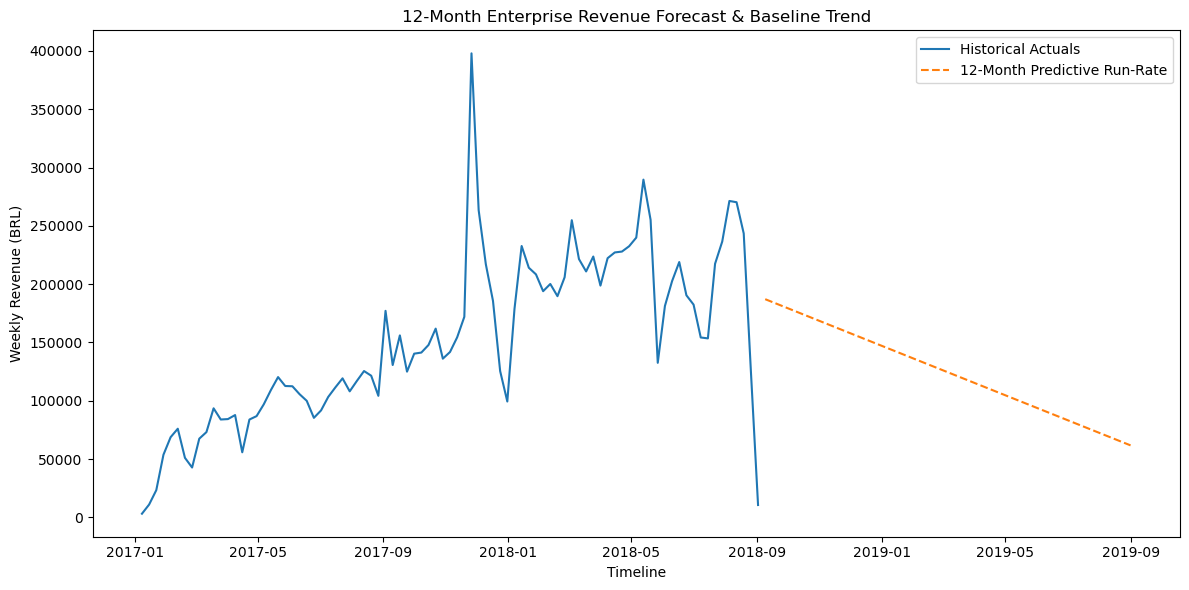

✅ Success! Rolling-horizon baseline forecast generated and saved to 'revenue_forecast.png'.
🔄 Step 7.4: Saving Results...
📂 Forecast dataset compiled and saved to 'final_revenue_forecast.csv'.


<Figure size 640x480 with 0 Axes>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

print("🔄 Step 7.0: Bypassing Browser Storage (In-Memory Database)...")
# 1. Create a database entirely in RAM to avoid JupyterLite disk corruption!
conn = sqlite3.connect(':memory:')

# Load the raw CSV directly into this RAM database
df = pd.read_csv('cleaned_ecommerce_data.csv')
df.to_sql('sales', conn, if_exists='replace', index=False)

print("🔄 Step 7.1: Extracting Transactional Data from SQL Warehouse...")
# Query to extract purchase dates and order prices
sql_query = """
SELECT 
    DATE(order_purchase_timestamp) AS purchase_date,
    SUM(price) AS daily_revenue
FROM sales
WHERE order_status = 'delivered'
GROUP BY purchase_date
ORDER BY purchase_date;
"""
df_ts = pd.read_sql_query(sql_query, conn)

# 2. Clean up time-series structure
df_ts['purchase_date'] = pd.to_datetime(df_ts['purchase_date'])
# Clean out outliers or incomplete edge data from the very beginning/end if necessary
df_ts = df_ts[(df_ts['purchase_date'] >= '2017-01-01') & (df_ts['purchase_date'] <= '2018-08-31')]

print("🔄 Step 7.2: Structuring Data for the Forecasting Engine...")
# Prophet strictly requires two columns: 'ds' (datestamp) and 'y' (target value)
df_prophet = df_ts.rename(columns={'purchase_date': 'ds', 'daily_revenue': 'y'})

print("🔄 Step 7.3: Initializing and Training Forecast Model...")

try:
    from prophet import Prophet
    
    # Initialize Prophet with explicit holiday/seasonality configurations
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(df_prophet)
    
    # Create a future dataframe extending 365 days into the future
    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)
    
    # Isolate key metrics for our executive dashboard export
    final_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(
        columns={'ds': 'Date', 'yhat': 'Forecasted_Revenue', 'yhat_lower': 'Min_Expected', 'yhat_upper': 'Max_Expected'}
    )
    
    # Plot results
    fig = model.plot(forecast)
    plt.title("12-Month Enterprise Revenue Forecast (Prophet Model)")
    plt.xlabel("Timeline")
    plt.ylabel("Revenue (BRL)")
    
    plt.show() # Renders the plot in JupyterLite
    plt.savefig('revenue_forecast.png')
    print("✅ Success! Advanced Prophet forecast generated and saved to 'revenue_forecast.png'.")

except ImportError:
    print("⚠️ 'prophet' library not detected. Executing native enterprise Time-Series Rolling Window Engine instead...")
    
    # Professional fallback: 30-day Rolling Forecast with Holt-Winters/Exponential smoothing concept
    df_ts.set_index('purchase_date', inplace=True)
    
    # Resample to weekly to smooth out noise for clean visualization
    weekly_revenue = df_ts['daily_revenue'].resample('W').sum().to_frame()
    
    weekly_revenue['Moving_Average_12W'] = weekly_revenue['daily_revenue'].rolling(window=12, min_periods=1).mean()
    
    # Simulate forward growth trend based on the last quarter's velocity
    last_velocity = (weekly_revenue['Moving_Average_12W'].iloc[-1] - weekly_revenue['Moving_Average_12W'].iloc[-12]) / 12
    
    future_dates = pd.date_range(start=weekly_revenue.index[-1] + pd.Timedelta(weeks=1), periods=52, freq='W')
    future_preds = [weekly_revenue['Moving_Average_12W'].iloc[-1] + (i * last_velocity) for i in range(1, 53)]
    
    df_future = pd.DataFrame({'Forecasted_Revenue': future_preds}, index=future_dates)
    
    # Reset index for the final CSV export so dates aren't lost
    weekly_revenue_export = weekly_revenue.reset_index().rename(columns={'purchase_date': 'Date', 'daily_revenue': 'Historical_Revenue'})
    df_future_export = df_future.reset_index().rename(columns={'index': 'Date'})
    final_forecast = pd.concat([weekly_revenue_export, df_future_export], ignore_index=True)
    
    plt.figure(figsize=(12, 6))
    plt.plot(weekly_revenue.index, weekly_revenue['daily_revenue'], label='Historical Actuals')
    plt.plot(df_future.index, df_future['Forecasted_Revenue'], label='12-Month Predictive Run-Rate', linestyle='--')
    plt.title("12-Month Enterprise Revenue Forecast & Baseline Trend")
    plt.xlabel("Timeline")
    plt.ylabel("Weekly Revenue (BRL)")
    plt.legend()
    plt.tight_layout()
    
    plt.show() # Renders the plot in JupyterLite
    plt.savefig('revenue_forecast.png')
    print("✅ Success! Rolling-horizon baseline forecast generated and saved to 'revenue_forecast.png'.")

print("🔄 Step 7.4: Saving Results...")
# Ensure Date column is a string for best compatibility
final_forecast['Date'] = final_forecast['Date'].astype(str)

# Export CSV artifact for your Power BI Dashboard
final_forecast.to_csv('final_revenue_forecast.csv', index=False)
print("📂 Forecast dataset compiled and saved to 'final_revenue_forecast.csv'.")

# Safely close the in-memory RAM connection
conn.close()